# PrimeKG nativo: capas bipartitas y planos homogéneos

El 2026-09-08 la reunión con Ariel se frenó en la lámina de los planos homogéneos de OptimusKG:
el plano `drug` tenía 4.290 aristas para 7.364 drogas, percolaba con kappa 1,5 y la relación que lo
armaba (`PARENT`) no era farmacológica. Sobre una red así DIAMOnD no tiene nada que recuperar. La
tesis sigue sobre PrimeKG, y antes de portar el experimento hay que mirar acá lo mismo que hizo
saltar esa alerta.

Este notebook mide dos cosas sobre PrimeKG nativo, para genes, enfermedades y fenotipos:

1. **Las capas bipartitas tal cual**: cómo se distribuye la cantidad de vecinos de la capa B que
   tiene cada nodo de la capa A, sin umbral de evidencia ni filtro sobre los nodos.
2. **Los planos homogéneos**: cuántos nodos con arista y cuántas aristas tiene la red de cada tipo,
   en cuántas componentes se parte, y si tiene componente gigante (kappa de Molloy y Reed).

Las drogas no entran a propósito: la capa de drogas de la tesis va a venir de otro grafo del
laboratorio.

**Los datos.** Son los CSV originales de PrimeKG (Chandak, Huang y Zitnik 2023) que vinieron en el
zip de Ingrid, en `datos_ingriz/datos_tesis_ingrid/external/`, sin ninguna limpieza. El CSV de
aristas guarda cada arista dos veces, una por sentido, y `datos_primekg.py` se ocupa de contar una
sola. Los números de OptimusKG con los que se compara salen del `README.md` de
`optimuskg/experimentacion_proyeccion/` y de su `metricas_planos.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import datos_primekg as datos

SEED = 42
pd.set_option("display.width", 160)

nodos = datos.cargar_nodos()
aristas = datos.cargar_aristas()
print("nodos por tipo:")
print(nodos.node_type.value_counts().to_string())

nodos por tipo:
node_type
gene/protein        27671
disease             17080
effect/phenotype    15311


## Qué relaciones hay entre los tres tipos

Cada fila es una relación del CSV entre dos de los tres tipos. `filas` es lo que trae el CSV y
`pares` es la cantidad de aristas de verdad, la mitad, porque cada una viene en los dos sentidos.

In [2]:
def par_de_tipos(fila):
    '''el par de tipos sin sentido, para que (disease, gene) y (gene, disease) cuenten juntos'''
    return " y ".join(sorted([fila.x_type, fila.y_type]))

conteo = aristas.assign(tipos=aristas.apply(par_de_tipos, axis=1))
conteo = conteo.groupby(["tipos", "relation", "display_relation"]).size().rename("filas").reset_index()
conteo["pares"] = conteo.filas // 2
conteo

,tipos,relation,display_relation,filas,pares
0,disease y disease,disease_disease,parent-child,64388,32194
1,disease y effect/phenotype,disease_phenotype_negative,phenotype absent,2386,1193
2,disease y effect/phenotype,disease_phenotype_positive,phenotype present,300634,150317
3,disease y gene/protein,disease_protein,associated with,160822,80411
4,effect/phenotype y effect/phenotype,phenotype_phenotype,parent-child,37472,18736
5,effect/phenotype y gene/protein,phenotype_protein,associated with,6660,3330
6,gene/protein y gene/protein,protein_protein,ppi,642150,321075


## 1. Las capas bipartitas tal cual

Para cada capa, cuántos vecinos de la capa B tiene cada nodo de la capa A, y al revés. Es la
misma figura que la página 1 del `paso0` de OptimusKG: la CCDF empírica del grado bipartito en
log-log, una curva por lado del par. "Tal cual" quiere decir sin umbral de evidencia ni filtro
sobre qué nodos entran.

In [3]:
capas = {nombre: datos.capa_bipartita(nombre) for nombre in datos.CAPAS}

filas_tabla = []
for nombre, pares in capas.items():
    tipo_a, tipo_b, relacion = datos.CAPAS[nombre]
    grados_a = pares.groupby("a").size()
    grados_b = pares.groupby("b").size()
    total_a = (nodos.node_type == tipo_a).sum()
    total_b = (nodos.node_type == tipo_b).sum()
    filas_tabla.append({
        "capa": nombre, "relacion": relacion, "pares": len(pares),
        "A": tipo_a, "A con vecinos en B": len(grados_a), "A total": total_a,
        "A con vecinos %": round(100 * len(grados_a) / total_a, 1),
        "A grado mediana": grados_a.median(), "A grado max": grados_a.max(),
        "B": tipo_b, "B con vecinos en A": len(grados_b), "B total": total_b,
        "B con vecinos %": round(100 * len(grados_b) / total_b, 1),
        "B grado mediana": grados_b.median(), "B grado max": grados_b.max(),
    })
tabla_capas = pd.DataFrame(filas_tabla).set_index("capa")
tabla_capas.T

capa,disease_gene,disease_phenotype,gene_phenotype
relacion,disease_protein,disease_phenotype_positive,phenotype_protein
pares,80411,150317,3330
A,disease,disease,gene/protein
A con vecinos en B,5593,6744,1621
A total,17080,17080,27671
A con vecinos %,32.7,39.5,5.9
A grado mediana,2.0,14.0,1.0
A grado max,1156,503,27
B,gene/protein,effect/phenotype,effect/phenotype
B con vecinos en A,9080,9404,356


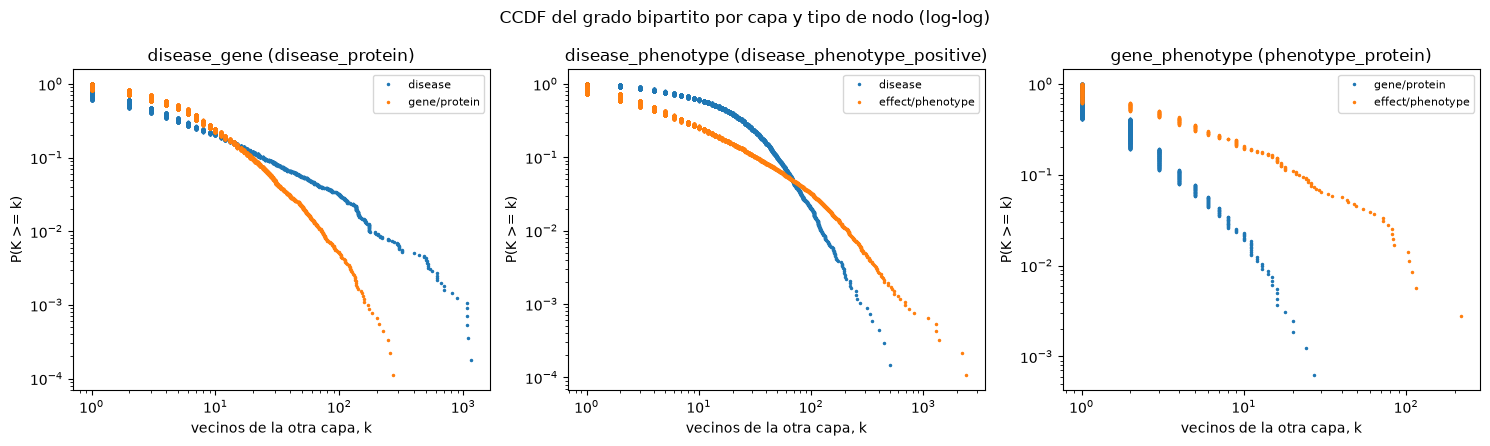

In [4]:
def ccdf(valores):
    '''retorna (x, fraccion >= x) para graficar en log-log. Copiada de paso0.py de OptimusKG.'''
    x = np.sort(np.asarray(valores))
    y = 1.0 - np.arange(len(x)) / len(x)
    return x, y


fig, ejes = plt.subplots(1, 3, figsize=(15, 4.5))
for eje, (nombre, pares) in zip(ejes, capas.items()):
    tipo_a, tipo_b, relacion = datos.CAPAS[nombre]
    for etiqueta, grados in [(tipo_a, pares.groupby("a").size()), (tipo_b, pares.groupby("b").size())]:
        x, y = ccdf(grados.values)
        eje.loglog(x, y, marker=".", linestyle="none", markersize=3, label=etiqueta)
    eje.set_title(f"{nombre} ({relacion})")
    eje.set_xlabel("vecinos de la otra capa, k")
    eje.set_ylabel("P(K >= k)")
    eje.legend(fontsize=8)
fig.suptitle("CCDF del grado bipartito por capa y tipo de nodo (log-log)")
fig.tight_layout()
plt.show()

## 2. Los planos homogéneos

La red de cada tipo con su única relación intracapa: el interactoma para los genes, y la
jerarquía padre-hijo de MONDO y de HPO para enfermedades y fenotipos (lo que en OptimusKG era
`PARENT`). Un nodo sin arista no está en el plano, igual que en OptimusKG.

Kappa es la media del grado al cuadrado sobre la media del grado. Si es mayor que 2 hay
componente gigante (criterio de Molloy y Reed, el que usa Menche et al. 2015 en la Fig. 1E).

In [5]:
planos = {nombre: datos.plano(nombre) for nombre in datos.PLANOS}


def kappa(grados):
    grados = np.asarray(grados, dtype=float)
    return float((grados ** 2).mean() / grados.mean())


filas_tabla = []
grados_por_plano = {}
componentes_por_plano = {}
for nombre, red in planos.items():
    tipo, relacion = datos.PLANOS[nombre]
    grados = np.array([grado for _, grado in red.degree()])
    componentes = sorted(nx.connected_components(red), key=len, reverse=True)
    grados_por_plano[nombre] = grados
    componentes_por_plano[nombre] = componentes
    filas_tabla.append({
        "plano": nombre, "relacion": relacion,
        "nodos del tipo": (nodos.node_type == tipo).sum(),
        "nodos con arista": red.number_of_nodes(),
        "aristas": red.number_of_edges(),
        "componentes": len(componentes),
        "LCC": len(componentes[0]),
        "LCC %": round(100 * len(componentes[0]) / red.number_of_nodes(), 1),
        "grado mediana": float(np.median(grados)),
        "grado max": int(grados.max()),
        "grado 1 %": round(100 * (grados == 1).mean(), 1),
        "kappa": round(kappa(grados), 1),
    })
tabla_planos = pd.DataFrame(filas_tabla).set_index("plano")
tabla_planos

,relacion,nodos del tipo,nodos con arista,aristas,componentes,LCC,LCC %,grado mediana,grado max,grado 1 %,kappa
plano,,,,,,,,,,,
gene,protein_protein,27671,18354,321075,5,18345,100.0,17.0,5197,7.5,187.3
disease,disease_disease,17080,17008,32194,1,17008,100.0,2.0,1524,38.9,67.1
phenotype,phenotype_phenotype,15311,14885,18736,58,14678,98.6,1.0,53,54.1,5.9


### Al lado de OptimusKG

Los números de OptimusKG son los del README del experimento (planos `INTERACTS_WITH` para gene y
`PARENT` para el resto, con `is_truly_disease` en disease) y los kappa de `metricas_planos.ipynb`.
La fila `drug` de OptimusKG es lo que disparó la alerta y queda como referencia de lo que sería un
plano que no sirve.

In [6]:
optimuskg = pd.DataFrame({
    "plano": ["gene", "disease", "phenotype", "drug"],
    "relacion OptimusKG": ["INTERACTS_WITH", "PARENT", "PARENT", "PARENT"],
    "nodos con arista OptimusKG": [18453, 15454, 19177, 7364],
    "aristas OptimusKG": [322163, 24813, 24862, 4290],
    "kappa OptimusKG": [187.0, 34.0, 7.8, 1.5],
}).set_index("plano")

comparacion = tabla_planos[["relacion", "nodos con arista", "aristas", "kappa"]].rename(columns={
    "relacion": "relacion PrimeKG", "nodos con arista": "nodos con arista PrimeKG",
    "aristas": "aristas PrimeKG", "kappa": "kappa PrimeKG"})
comparacion = comparacion.join(optimuskg, how="outer").loc[["gene", "disease", "phenotype", "drug"]]
comparacion

,relacion PrimeKG,nodos con arista PrimeKG,aristas PrimeKG,kappa PrimeKG,relacion OptimusKG,nodos con arista OptimusKG,aristas OptimusKG,kappa OptimusKG
plano,,,,,,,,
gene,protein_protein,18354.0,321075.0,187.3,INTERACTS_WITH,18453,322163,187.0
disease,disease_disease,17008.0,32194.0,67.1,PARENT,15454,24813,34.0
phenotype,phenotype_phenotype,14885.0,18736.0,5.9,PARENT,19177,24862,7.8
drug,NaN,NaN,NaN,NaN,PARENT,7364,4290,1.5


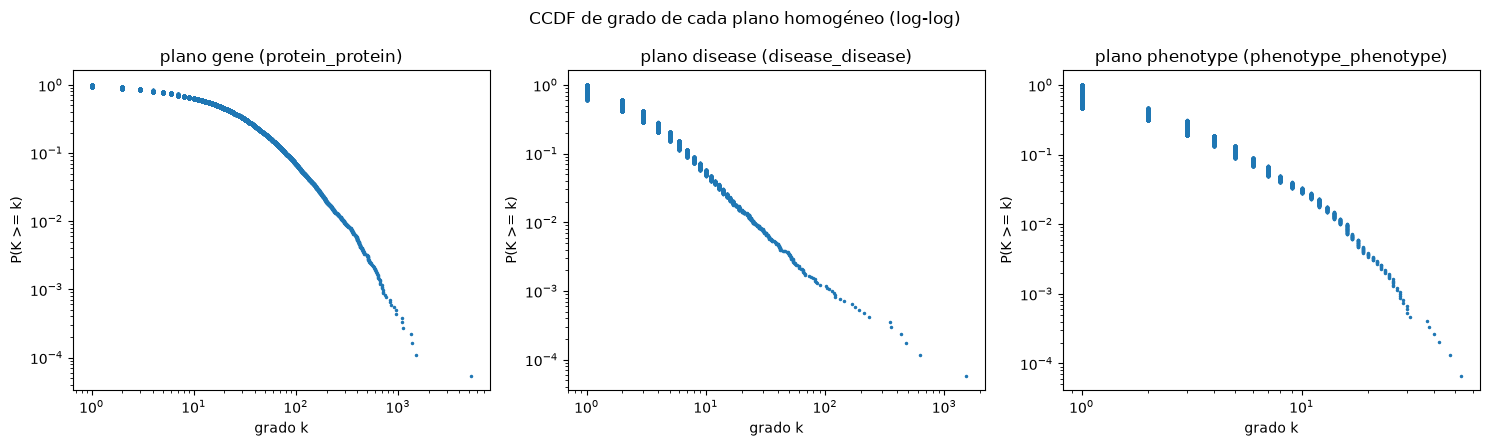

In [7]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 4.5))
for eje, (nombre, grados) in zip(ejes, grados_por_plano.items()):
    x, y = ccdf(grados)
    eje.loglog(x, y, marker=".", linestyle="none", markersize=3)
    eje.set_title(f"plano {nombre} ({datos.PLANOS[nombre][1]})")
    eje.set_xlabel("grado k")
    eje.set_ylabel("P(K >= k)")
fig.suptitle("CCDF de grado de cada plano homogéneo (log-log)")
fig.tight_layout()
plt.show()

### Fragmentación y percolación

A la izquierda, cuántas componentes hay de cada tamaño. A la derecha, la curva de percolación de
Menche et al. 2015 (Fig. 1E): se conserva una fracción p de las aristas elegidas al azar y se
mide qué fracción de los nodos queda en la componente mayor. Un plano con componente gigante
robusta se mantiene alto hasta p chico; uno fragmentado cae enseguida.

gene: 5 componentes, la mayor de 18345 nodos, 0.0% de los nodos en componentes de 2 o 3
disease: 1 componentes, la mayor de 17008 nodos, 0.0% de los nodos en componentes de 2 o 3
phenotype: 58 componentes, la mayor de 14678 nodos, 0.7% de los nodos en componentes de 2 o 3


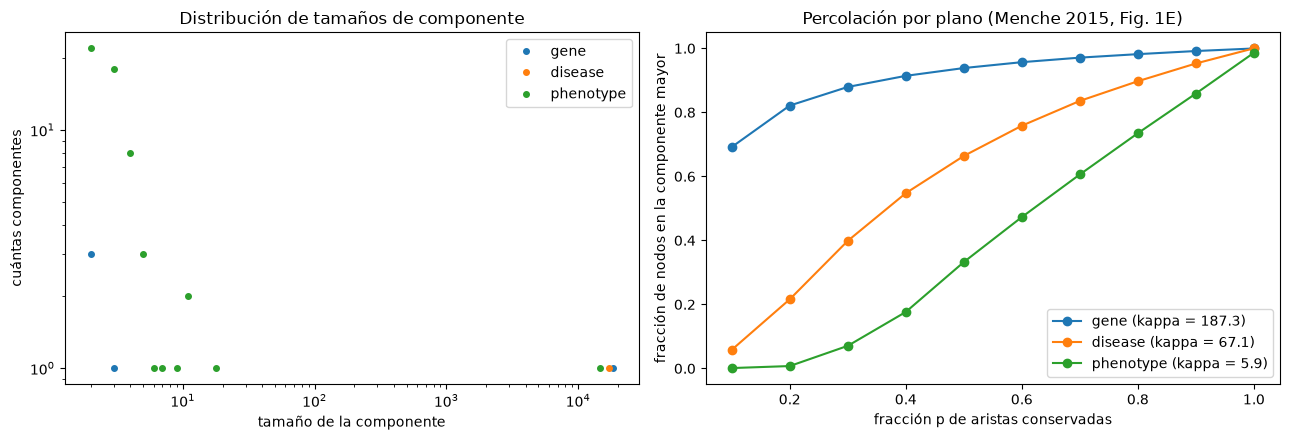

In [8]:
def curva_de_percolacion(red, fracciones, repeticiones=10, seed=SEED):
    '''Para cada p, la fraccion media de nodos en la componente mayor al conservar una fraccion p
    de las aristas, elegidas al azar. Portada de armar_metricas_planos.py de OptimusKG a networkx.'''
    lista = np.array(red.edges())
    n = red.number_of_nodes()
    rng = np.random.default_rng(seed)
    medias = []
    for p in fracciones:
        valores = []
        for _ in range(repeticiones):
            elegidas = rng.random(len(lista)) < p
            g = nx.Graph()
            g.add_nodes_from(red.nodes())
            g.add_edges_from(lista[elegidas])
            valores.append(len(max(nx.connected_components(g), key=len)) / n)
        medias.append(np.mean(valores))
    return medias


fracciones = np.arange(0.1, 1.01, 0.1)
fig, (izq, der) = plt.subplots(1, 2, figsize=(13, 4.5))
for nombre, componentes in componentes_por_plano.items():
    tamanos = np.array([len(c) for c in componentes])
    valores, cuantas = np.unique(tamanos, return_counts=True)
    izq.loglog(valores, cuantas, marker="o", linestyle="none", markersize=4, label=nombre)
    chicas = tamanos[(tamanos >= 2) & (tamanos <= 3)].sum() / tamanos.sum()
    print(f"{nombre}: {len(componentes)} componentes, la mayor de {tamanos.max()} nodos, "
          f"{100 * chicas:.1f}% de los nodos en componentes de 2 o 3")
izq.set_xlabel("tamaño de la componente")
izq.set_ylabel("cuántas componentes")
izq.set_title("Distribución de tamaños de componente")
izq.legend()

for nombre, red in planos.items():
    curva = curva_de_percolacion(red, fracciones)
    der.plot(fracciones, curva, marker="o", label=f"{nombre} (kappa = {kappa(grados_por_plano[nombre]):.1f})")
der.set_xlabel("fracción p de aristas conservadas")
der.set_ylabel("fracción de nodos en la componente mayor")
der.set_title("Percolación por plano (Menche 2015, Fig. 1E)")
der.legend()
fig.tight_layout()
plt.show()

## 3. Los hubs de cada plano

En OptimusKG el problema no fue solo el número: también qué significaba la relación. Acá, los diez
nodos de mayor grado de cada plano con su nombre. En disease y phenotype se espera ver los
paraguas de MONDO y HPO, el mismo tipo de nodo que en OptimusKG hacía degenerar el nulo de la
iteración 0 en los planos taxonómicos.

In [9]:
tablas = []
for nombre, red in planos.items():
    grados = pd.Series(dict(red.degree())).sort_values(ascending=False).head(10)
    tabla = pd.DataFrame({
        "plano": nombre,
        "node_id": nodos.loc[grados.index, "node_id"].values,
        "nombre": nodos.loc[grados.index, "node_name"].values,
        "grado": grados.values,
    })
    tablas.append(tabla)
pd.concat(tablas).set_index(["plano", "nombre"])

node_id  grado
plano     nombre                                                           
gene      UBC                                                   7316   5197
          ETS1                                                  2113   1492
          GATA2                                                 2624   1363
          CTCF                                                 10664   1351
          EP300                                                 2033   1117
          AR                                                     367   1099
          MYC                                                   4609   1099
          RAD21                                                 5885    961
          APP                                                    351    954
          EGR1                                                  1958    908
disease   Mendelian disease                                     3847   1524
          syndromic disease                                     2254    622
          congenital nervous system disorder                    2320    475
          syndromic intellectual disability                      508    438
          genetic nervous system disorder                      19117    358
          multiple congenital anomalies/dysmorphic syndro...   15159    348
          genetic multiple congenital anomalies/dysmorphi...   43005    236
          hereditary connective tissue disorder                23603    211
          autosomal recessive disease                           6025    194
          syndromic genetic deafness                           19589    178
phenotype Abnormal circulating protein concentration           10876     53
          Abnormal enzyme/coenzyme activity                    12379     47
          Autoimmune antibody positivity                       30057     42
          Abnormal urine metabolite level                      33354     40
          Behavioral abnormality                                 708     38
          Abnormal skeletal muscle morphology                  11805     37
          Abnormal foot morphology                              1760     31
          Localized skin lesion                                11355     30
          Abnormality of the pinna                               377     30
          Triggered by                                         25204     30

## Lectura

**Capas bipartitas.** Las capas enfermedad a gen y enfermedad a fenotipo tienen con qué trabajar:
un tercio de las enfermedades tiene genes asociados (mediana 2, máximo 1.156) y el 40 % tiene
fenotipos (mediana 14 por enfermedad, y el 61 % de los fenotipos cuelga de alguna enfermedad). La
capa gen a fenotipo es casi inexistente: 3.330 pares, el 6 % de los genes y el 2 % de los
fenotipos. En OptimusKG esa capa era `ASSOCIATED_WITH` entre Gene y Phenotype; acá las celdas que
salen de un gen hacia fenotipos o de un fenotipo hacia genes van a tener muy pocas anclas.

**Planos homogéneos.** Lo que disparó la alerta el 8/9 no se repite en ninguno de los tres planos:
ninguno tiene kappa menor que 2 ni se parte en parejas. El plano `gene` es prácticamente la misma
red que el interactoma de OptimusKG (18.354 nodos y 321.075 aristas contra 18.453 y 322.163, kappa
187 en los dos). El plano `disease` es la jerarquía de MONDO entera, una sola componente con kappa
67, más conectada que el `PARENT` de OptimusKG con `is_truly_disease` (kappa 34), pero con la misma
estructura de árbol: el 39 % de los nodos tiene grado 1 y los hubs son los paraguas. El plano
`phenotype` es el más flaco: kappa 5,9 (7,8 en OptimusKG), mediana de grado 1, 54 % de nodos con
grado 1, grado máximo 53, y la curva de percolación cae casi en línea recta. Está por encima del
umbral de Molloy y Reed, pero es un árbol casi puro.

**Hubs.** En `gene` son los hubs clásicos del interactoma (UBC con 5.197, ETS1, GATA2, CTCF,
EP300). En `disease` son los paraguas de MONDO: "Mendelian disease" con 1.524 hijos, "syndromic
disease", "congenital nervous system disorder". Es el mismo tipo de nodo que en OptimusKG hacía
degenerar el nulo de la iteración 0 en los planos taxonómicos, y acá con grados mayores. En
`phenotype` los hubs son categorías intermedias de HPO con grado 53 como máximo, y aparece
"Triggered by", que es un modificador y no un fenotipo.

Qué hacer con los paraguas de MONDO y con la capa gen a fenotipo es una decisión de método para
hablar con Ariel, no de este notebook.